# Stiffness diagnostics for a PySR per-minute marker formula


This notebook reproduces a marker-specific per-minute formula (PySR or Linear Regression) from the functional groups summary and runs quick stiffness checks on the resulting ODE with `diffrax`. We start from a single GFP bin of `EGFR` and build helper utilities to compare Tsit5 versus a stiff integrator before sweeping across solver/tolerance settings.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

import jax.numpy as jnp
from diffrax import (
    ODETerm,
    diffeqsolve,
    Tsit5,
    Kvaerno5,
    PIDController,
    SaveAt,
    RESULTS,
)
from IPython.display import display

plt.style.use("seaborn-v0_8")


In [2]:

DATA_ROOT = Path("../data/experimental")
SUMMARY_PATH = DATA_ROOT / "functional_groups/outputs/reports/summary/functional_group_summary.csv"
DATASET_PATH = DATA_ROOT / "processed/functional_groups/functional_groups_per_minute_fit.csv"

MARKER = "DYRK3"
ACTIVE_MODEL = "PySR"
MODEL_OPTIONS = ("PySR", "Linear Regression")
GFP_BIN = None  # pick the first available bin if unspecified

STATE_CLAMP = (0.0, 1e6)
DERIV_CLIP = 1e6
MAX_STEPS = int(2e5)
GRID_POINTS = 300

EXCLUDE_COLUMNS = {"p-ERK1-2_dt", "p-MEK1-2_dt", "marker", "timepoint", "GFP_bin"}
TARGET_COLUMN = "p_ERK1_2_dt"
STATE_COLUMN = "p_ERK1_2"
MEASURED_TIMEPOINTS = [0.0, 5.0, 10.0, 15.0, 30.0, 60.0]


In [3]:

def sanitize_feature_names(columns):
    renamed = []
    for col in columns:
        clean = col.replace("-", "_").replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        if clean and clean[0].isdigit():
            clean = f"f_{clean}"
        renamed.append(clean)
    return renamed


def prepare_dataset(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.replace("_fit$", "", regex=True)
    target_col = sanitize_feature_names(["p-ERK1-2_dt"])[0]
    candidate_cols = [c for c in df.columns if c not in EXCLUDE_COLUMNS]
    df.rename(columns=dict(zip(candidate_cols, sanitize_feature_names(candidate_cols))), inplace=True)
    df[target_col] = pd.to_numeric(df.get("p-ERK1-2_dt", df.get(target_col)), errors="coerce")
    if "marker" in df.columns:
        df["marker"] = df["marker"].astype(str)
    if "GFP_bin" in df.columns:
        df["GFP_bin"] = pd.to_numeric(df["GFP_bin"], errors="coerce")
    if "timepoint" in df.columns:
        df["timepoint"] = pd.to_numeric(df["timepoint"], errors="coerce")
    return df, target_col


def load_formula(summary_path, marker, model, dataset_mode="per_minute"):
    summary = pd.read_csv(summary_path)
    subset = summary[(summary["group_name"] == marker) & (summary["model"] == model)]
    if "dataset_mode" in subset.columns:
        subset = subset[subset["dataset_mode"] == dataset_mode]
    if subset.empty:
        raise ValueError(f"No rows for marker={marker}, model={model}, mode={dataset_mode}")
    formula = subset.iloc[0]["formula"]
    if not isinstance(formula, str) or formula == "N/A":
        raise ValueError("Formula missing for selection")
    return formula


def evaluate_formula(formula, features):
    expr = sp.sympify(formula)
    symbols = sorted({str(s) for s in expr.free_symbols})
    for m in symbols:
        if m not in features.columns:
            features[m] = 0.0
    func = sp.lambdify(symbols, expr, "numpy")
    arrays = [features[s].to_numpy(dtype=float) for s in symbols] if symbols else []
    vals = func(*arrays) if symbols else np.full(len(features), float(expr))
    vals = np.asarray(vals, dtype=float).reshape(-1)
    vals[~np.isfinite(vals)] = np.nan
    return vals


def build_rhs(formula, backend="jax"):
    expr = sp.sympify(formula)
    symbols = sorted(expr.free_symbols, key=lambda s: s.name)
    func = sp.lambdify(symbols, expr, backend)
    return func, [s.name for s in symbols]


def compute_r2(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return np.nan
    yt = y_true[mask]
    yp = y_pred[mask]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def build_model_context(model_name, formula, bin_df, target_col):
    """Precompute diffrax inputs for one model so multiple solvers
    can reuse them."""
    rhs_jax, symbol_names = build_rhs(formula, backend="jax")
    rhs_np, _ = build_rhs(formula, backend="numpy")
    p_symbol = sanitize_feature_names(["p-ERK1-2"])[0]

    time_points = bin_df["timepoint"].to_numpy(dtype=float)
    obs_state = bin_df[STATE_COLUMN].to_numpy(dtype=float)
    feature_columns = [c for c in bin_df.columns if c not in EXCLUDE_COLUMNS and c != target_col]
    feature_arrays_np = {}
    for col in feature_columns:
        arr = pd.to_numeric(bin_df[col], errors="coerce").to_numpy(dtype=float)
        feature_arrays_np[col] = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    for name in symbol_names:
        if name == p_symbol:
            continue
        feature_arrays_np.setdefault(name, np.zeros_like(time_points))

    feature_arrays_jnp = {name: jnp.asarray(feature_arrays_np[name], dtype=float) for name in feature_arrays_np}
    t_jnp = jnp.asarray(time_points, dtype=float)

    t0, t1 = float(time_points[0]), float(time_points[-1])
    time_grid_np = np.linspace(t0, t1, GRID_POINTS)
    saveat = SaveAt(ts=jnp.asarray(time_grid_np, dtype=float))
    y0 = jnp.asarray([obs_state[0]], dtype=float)
    dt0 = max(1e-6, float((time_points[-1] - time_points[0]) / max(10, len(time_points))))

    def _ode_fun(t, y, _args):
        vals = []
        for name in symbol_names:
            if name == p_symbol:
                vals.append(jnp.clip(y[0], STATE_CLAMP[0], STATE_CLAMP[1]))
            else:
                vals.append(jnp.interp(t, t_jnp, feature_arrays_jnp[name]))
        deriv = rhs_jax(*vals)
        deriv = jnp.clip(deriv, -DERIV_CLIP, DERIV_CLIP)
        return jnp.reshape(deriv, (1,))

    term = ODETerm(_ode_fun)
    return {
        "model": model_name,
        "formula": formula,
        "symbol_names": symbol_names,
        "p_symbol": p_symbol,
        "rhs_np": rhs_np,
        "rhs_jax": rhs_jax,
        "term": term,
        "t0": t0,
        "t1": t1,
        "y0": y0,
        "saveat": saveat,
        "dt0": dt0,
        "time_points": time_points,
        "obs_state": obs_state,
        "feature_arrays_np": feature_arrays_np,
        "feature_arrays_jnp": feature_arrays_jnp,
        "bin_df": bin_df,
        "target_col": target_col,
    }


## Dataset selection and formula overview

In [4]:
df, target_col = prepare_dataset(DATASET_PATH)
marker_df = df[df["marker"] == MARKER].copy()
if marker_df.empty:
    raise ValueError(f"No rows found for marker={MARKER}")
marker_df = marker_df.dropna(subset=[target_col, "timepoint", "GFP_bin"])
if marker_df.empty:
    raise ValueError("No marker rows with finite timepoint/target/GFP_bin")

bins = sorted(marker_df["GFP_bin"].dropna().unique())
if not bins:
    raise ValueError("No numeric GFP_bin values for this marker")
if GFP_BIN is None:
    GFP_BIN = bins[0]
bin_df = marker_df[marker_df["GFP_bin"] == GFP_BIN].copy()
bin_df.sort_values("timepoint", inplace=True)
bin_df = bin_df.dropna(subset=[STATE_COLUMN, target_col, "timepoint"]).reset_index(drop=True)
if len(bin_df) < 2:
    raise ValueError("Need at least two timepoints after cleaning")

print(f"Marker={MARKER} | GFP bin={GFP_BIN} | rows={len(bin_df)} | time span {bin_df['timepoint'].min()} → {bin_df['timepoint'].max()}")

features = bin_df[[c for c in bin_df.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
model_formulas = {}
MODEL_CONTEXTS = {}
for model in MODEL_OPTIONS:
    try:
        formula = load_formula(SUMMARY_PATH, MARKER, model, "per_minute")
    except ValueError as exc:
        print(f"{model}: {exc}")
        continue
    preds = evaluate_formula(formula, features)
    model_formulas[model] = formula
    r2 = compute_r2(bin_df[target_col].to_numpy(dtype=float), preds)
    print(f"{model}: dt R² = {r2:.4f} | formula: {formula}")
    MODEL_CONTEXTS[model] = build_model_context(model, formula, bin_df, target_col)

if not MODEL_CONTEXTS:
    raise ValueError("No usable models available for diagnostics.")
print(f"Prepared contexts for models: {list(MODEL_CONTEXTS.keys())}")


Marker=DYRK3 | GFP bin=0 | rows=61 | time span 0.0 → 60.0
PySR: dt R² = 0.8422 | formula: (0.88387936 - p_RAF*p_p90RSK)*p_ERK1_2*(-2.788203)*(p_RAF - 0.73300195)
Linear Regression: dt R² = 0.7987 | formula: 0.0867 -0.0920 * GFP -0.3566 * p_ERK1_2 -0.0474 * p_ERK1_2_min +0.9698 * p_MEK1_2 -0.0191 * p_MEK1_2_min -0.6642 * p_RAF -0.1912 * p_p90RSK -0.1537 * p_MAPKAPK2 -0.1070 * p_PDK1 -0.0515 * p_MKK3_6
Prepared contexts for models: ['PySR', 'Linear Regression']


## Build the ODE term for the selected formula

In [5]:
if ACTIVE_MODEL not in MODEL_CONTEXTS:
    ACTIVE_MODEL = next(iter(MODEL_CONTEXTS.keys()))
print(f"Default ACTIVE_MODEL set to {ACTIVE_MODEL} (formula length={len(MODEL_CONTEXTS[ACTIVE_MODEL]['formula'])})")


Default ACTIVE_MODEL set to PySR (formula length=71)


## Helpers for running diagnostics

In [6]:
def run_config(context, solver, rtol, atol):
    controller = PIDController(rtol=rtol, atol=atol)
    return diffeqsolve(
        context["term"],
        solver=solver,
        t0=context["t0"],
        t1=context["t1"],
        y0=context["y0"],
        args=(),
        stepsize_controller=controller,
        saveat=context["saveat"],
        dt0=context["dt0"],
        max_steps=MAX_STEPS,
        throw=False,
    )


def evaluate_rhs_numpy(context, time_values, state_values):
    clipped_state = np.clip(state_values, STATE_CLAMP[0], STATE_CLAMP[1])
    args = []
    for name in context["symbol_names"]:
        if name == context["p_symbol"]:
            args.append(clipped_state)
        else:
            args.append(np.interp(time_values, context["time_points"], context["feature_arrays_np"][name]))
    deriv = context["rhs_np"](*args)
    return np.clip(np.asarray(deriv, dtype=float), -DERIV_CLIP, DERIV_CLIP)


def summarise(sol, label):
    print(f"--- {label} ---")
    print("result:", sol.result)
    stats = getattr(sol, "stats", {}) or {}
    num_steps = stats.get("num_steps")
    accepted = stats.get("num_accepted_steps")
    rejected = stats.get("num_rejected_steps")
    print("steps:", num_steps, "accepted:", accepted, "rejected:", rejected)
    sol_vals = np.asarray(sol.ys)
    contains_bad = not np.isfinite(sol_vals).all()
    print("contains NaN/Inf:", contains_bad)


def _to_scalar(value):
    if value is None:
        return None
    try:
        if hasattr(value, "item"):
            return value.item()
    except Exception:
        pass
    try:
        return float(value)
    except Exception:
        return value


## Diagnostic baseline with Tsit5

=== PySR: Tsit5 diagnostic ===
--- PySR | Tsit5 medium tolerances ---
result: diffrax._solution.RESULTS<>
steps: 112 accepted: 54 rejected: 58
contains NaN/Inf: False
=== Linear Regression: Tsit5 diagnostic ===
--- Linear Regression | Tsit5 medium tolerances ---
result: diffrax._solution.RESULTS<>
steps: 101 accepted: 53 rejected: 48
contains NaN/Inf: False


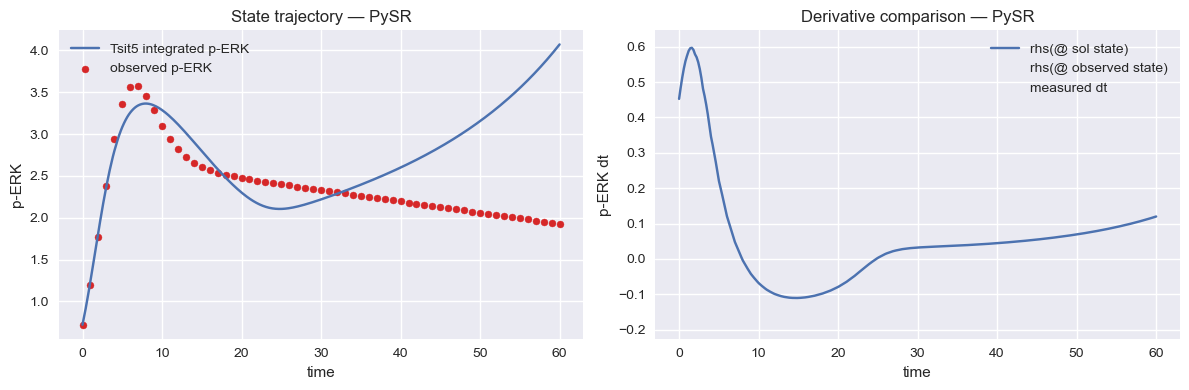

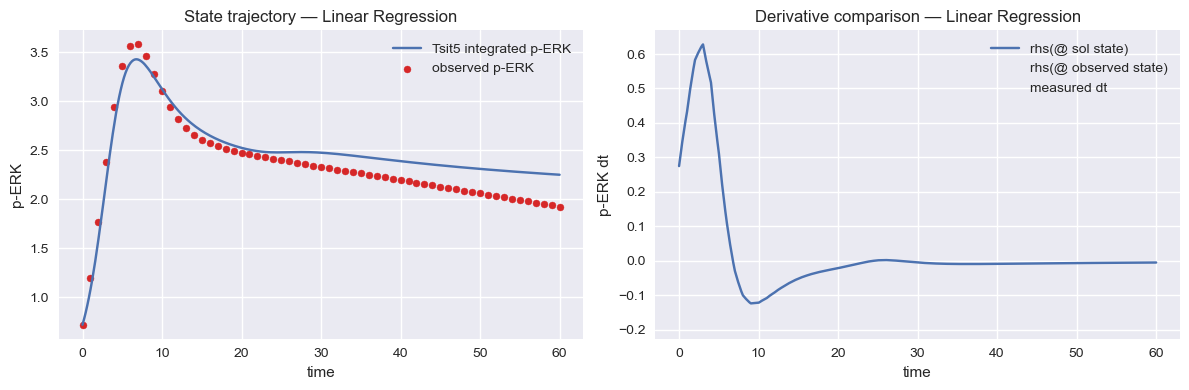

In [7]:
for model_name, context in MODEL_CONTEXTS.items():
    print(f"=== {model_name}: Tsit5 diagnostic ===")
    sol_tsit5 = run_config(context, Tsit5(), rtol=1e-6, atol=1e-8)
    summarise(sol_tsit5, f"{model_name} | Tsit5 medium tolerances")

    sol_times = np.asarray(sol_tsit5.ts)
    sol_vals = np.asarray(sol_tsit5.ys)
    sol_trace = sol_vals[:, 0] if sol_vals.ndim > 1 else sol_vals

    pred_rhs_grid = evaluate_rhs_numpy(context, sol_times, sol_trace)
    obs_rhs = evaluate_rhs_numpy(context, context["time_points"], context["obs_state"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(sol_times, sol_trace, label="Tsit5 integrated p-ERK")
    axes[0].scatter(context["time_points"], context["obs_state"], color="tab:red", label="observed p-ERK", s=25)
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("p-ERK")
    axes[0].legend()
    axes[0].set_title(f"State trajectory — {model_name}")

    axes[1].plot(sol_times, pred_rhs_grid, label="rhs(@ sol state)")
    axes[1].plot(context["time_points"], obs_rhs, "+", label="rhs(@ observed state)", alpha=0.7)
    axes[1].plot(context["time_points"], bin_df[target_col], "x", label="measured dt", alpha=0.7)
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("p-ERK dt")
    axes[1].legend()
    axes[1].set_title(f"Derivative comparison — {model_name}")

    plt.tight_layout()


## Stiff solver comparison

In [8]:
for model_name, context in MODEL_CONTEXTS.items():
    print(f"{model_name}: Kvaerno5 diagnostic")
    sol_kvaerno = run_config(context, Kvaerno5(), rtol=1e-6, atol=1e-8)
    summarise(sol_kvaerno, f"{model_name} | Kvaerno5 medium tolerances")


PySR: Kvaerno5 diagnostic
--- PySR | Kvaerno5 medium tolerances ---
result: diffrax._solution.RESULTS<>
steps: 124 accepted: 63 rejected: 61
contains NaN/Inf: False
Linear Regression: Kvaerno5 diagnostic
--- Linear Regression | Kvaerno5 medium tolerances ---
result: diffrax._solution.RESULTS<>
steps: 176 accepted: 85 rejected: 91
contains NaN/Inf: False


## Grid search over solver + tolerance combinations

Working configs sorted by model + step count


,model,solver,rtol,atol,num_steps,num_rejected,rejection_ratio,reached_max_steps,rhs_r2,rhs_rmse
27,Linear Regression,Kvaerno5,0.001000,1.000000e-05,10,0,0.000000,False,0.971846,0.027743
28,Linear Regression,Kvaerno5,0.001000,1.000000e-06,10,0,0.000000,False,0.972035,0.027650
29,Linear Regression,Kvaerno5,0.001000,1.000000e-08,10,0,0.000000,False,0.972061,0.027637
18,Linear Regression,Tsit5,0.001000,1.000000e-05,14,2,0.142857,False,0.972028,0.027653
19,Linear Regression,Tsit5,0.001000,1.000000e-06,14,2,0.142857,False,0.972005,0.027665
20,Linear Regression,Tsit5,0.001000,1.000000e-08,14,2,0.142857,False,0.972005,0.027665
31,Linear Regression,Kvaerno5,0.000100,1.000000e-06,16,2,0.125000,False,0.971713,0.027809
32,Linear Regression,Kvaerno5,0.000100,1.000000e-08,16,2,0.125000,False,0.971793,0.027769
30,Linear Regression,Kvaerno5,0.000100,1.000000e-05,18,4,0.222222,False,0.972030,0.027652
23,Linear Regression,Tsit5,0.000100,1.000000e-08,20,3,0.150000,False,0.971962,0.027686


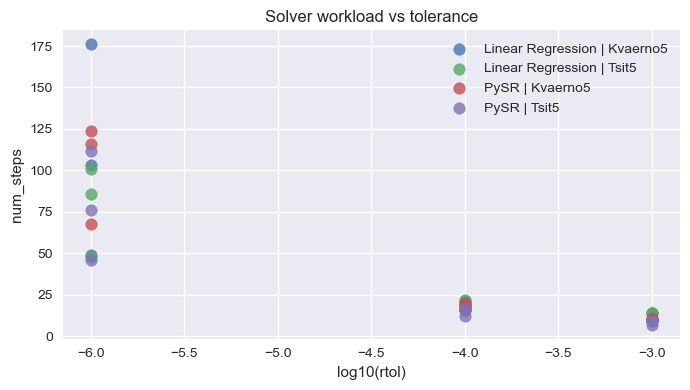

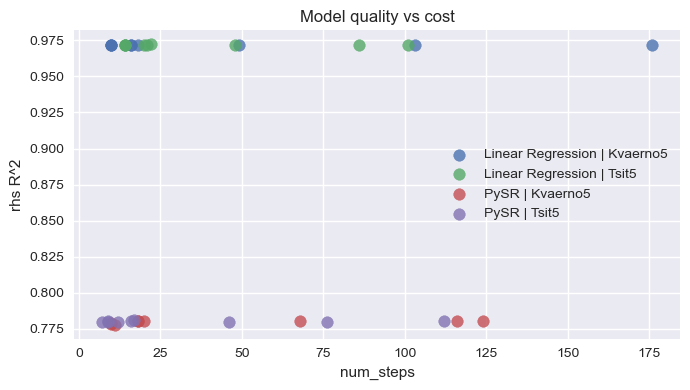

In [9]:
results = []
solvers = [("Tsit5", Tsit5), ("Kvaerno5", Kvaerno5)]
for model_name, context in MODEL_CONTEXTS.items():
    obs_dt = bin_df[target_col].to_numpy(dtype=float)
    for solver_name, solver_cls in solvers:
        for rtol in (1e-3, 1e-4, 1e-6):
            for atol in (1e-5, 1e-6, 1e-8):
                sol = run_config(context, solver_cls(), rtol=rtol, atol=atol)
                stats = getattr(sol, "stats", {}) or {}
                num_steps = _to_scalar(stats.get("num_steps"))
                num_rej = _to_scalar(stats.get("num_rejected_steps", 0))
                num_acc = _to_scalar(stats.get("num_accepted_steps"))
                sol_vals = np.asarray(sol.ys)
                finite = np.isfinite(sol_vals).all()
                ratio = num_rej / num_steps if num_steps else np.nan
                reached_max_steps = bool(
                    stats.get("reached_max_steps")
                    or stats.get("max_steps_reached")
                    or (num_steps is not None and num_steps >= MAX_STEPS)
                )

                sol_times = np.asarray(sol.ts)
                sol_state = np.asarray(sol.ys)
                if sol_state.ndim > 1:
                    sol_state = sol_state[:, 0]
                rhs_r2 = np.nan
                rhs_rmse = np.nan
                if sol_times.size >= 2 and np.all(np.isfinite(sol_times)):
                    try:
                        interp_state = np.interp(context["time_points"], sol_times, sol_state)
                        rhs_vals = evaluate_rhs_numpy(context, context["time_points"], interp_state)
                        diffs = rhs_vals - obs_dt
                        mask = np.isfinite(rhs_vals) & np.isfinite(obs_dt)
                        if mask.sum() > 1:
                            rhs_rmse = float(np.sqrt(np.mean(diffs[mask] ** 2)))
                            rhs_r2 = compute_r2(obs_dt, rhs_vals)
                    except Exception:
                        pass

                working = (
                    sol.result == RESULTS.successful
                    and finite
                    and num_steps
                    and num_steps > 0
                    and not reached_max_steps
                    and (ratio < 0.5 if not np.isnan(ratio) else False)
                )

                results.append({
                    "model": model_name,
                    "solver": solver_name,
                    "rtol": rtol,
                    "atol": atol,
                    "num_steps": num_steps,
                    "num_rejected": num_rej,
                    "num_accepted": num_acc,
                    "result": str(sol.result),
                    "rejection_ratio": float(ratio) if not np.isnan(ratio) else np.nan,
                    "reached_max_steps": reached_max_steps,
                    "rhs_r2": rhs_r2,
                    "rhs_rmse": rhs_rmse,
                    "working": bool(working),
                })

res_df = pd.DataFrame(results)
working_df = res_df[res_df["working"]].copy()
working_df.sort_values(["model", "num_steps"], inplace=True)
if working_df.empty:
    print("No working configurations found.")
else:
    print("Working configs sorted by model + step count")
    display(
        working_df[[
            "model",
            "solver",
            "rtol",
            "atol",
            "num_steps",
            "num_rejected",
            "rejection_ratio",
            "reached_max_steps",
            "rhs_r2",
            "rhs_rmse",
        ]]
    )

res_df["log10_rtol"] = np.log10(res_df["rtol"])
plt.figure(figsize=(7, 4))
for (model_name, solver_name), group in res_df.groupby(["model", "solver"]):
    mask = group["num_steps"].notna()
    plt.scatter(
        group.loc[mask, "log10_rtol"],
        group.loc[mask, "num_steps"],
        label=f"{model_name} | {solver_name}",
        s=70,
        alpha=0.8,
    )
plt.xlabel("log10(rtol)")
plt.ylabel("num_steps")
plt.title("Solver workload vs tolerance")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 4))
for (model_name, solver_name), group in res_df.groupby(["model", "solver"]):
    mask = group["num_steps"].notna() & group["rhs_r2"].notna()
    if not mask.any():
        continue
    plt.scatter(
        group.loc[mask, "num_steps"],
        group.loc[mask, "rhs_r2"],
        label=f"{model_name} | {solver_name}",
        s=70,
        alpha=0.8,
    )
plt.xlabel("num_steps")
plt.ylabel("rhs R^2")
plt.title("Model quality vs cost")
plt.grid(True)
plt.legend()
plt.tight_layout()
